In [ ]:
!pip -q install datasets transformers accelerate scikit-learn pandas numpy

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

import random
import numpy as np
import pandas as pd

from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_NAME = "OSS-forge/HumanVsAICode"

# train size n은 "Human n + LLM n"을 의미합니다.
TRAIN_SIZES = [10, 20, 50, 100, 200, 400, 800, 1200]

# test data는 고정: Human 500 + LLM 500
TEST_PER_CLASS = 500

# 전체 원본 row 샘플 수.
# None으로 두면 전체 데이터셋을 사용합니다.
# Colab에서 빠르게 실험하려면 6000 정도면 충분합니다.
SAMPLE_ORIGINAL_ROWS = 6000

# None, "python", "java" 중 선택 가능
# 논문용이면 LANGUAGE=None 전체 / LANGUAGE="python" / LANGUAGE="java"를 나눠 돌려도 좋습니다.
LANGUAGE = "python"

TEST_SIZE = 0.2

raw = load_dataset(DATASET_NAME)

if isinstance(raw, DatasetDict):
    ds = concatenate_datasets([raw[split] for split in raw.keys()])
else:
    ds = raw

print("Loaded rows:", len(ds))
print("Columns:", ds.column_names)

# 언어 필터링
lang_col = None
for c in ["language", "lang", "programming_language"]:
    if c in ds.column_names:
        lang_col = c
        break

if LANGUAGE is not None and lang_col is not None:
    ds = ds.filter(lambda x: str(x[lang_col]).lower() == LANGUAGE.lower())
    print(f"After language filter = {LANGUAGE}:", len(ds))
elif LANGUAGE is not None and lang_col is None:
    print("WARNING: language column not found. LANGUAGE filter skipped.")

AI_COLS = [c for c in ["chatgpt_code", "deepseek_code", "qwen_code"] if c in ds.column_names]

assert "human_code" in ds.column_names, "human_code column not found"
assert len(AI_COLS) > 0, "AI code columns not found"

print("AI columns:", AI_COLS)
print("Train sizes per class:", TRAIN_SIZES)
print("Fixed test per class:", TEST_PER_CLASS)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

java_dataset.jsonl:   0%|          | 0.00/505M [00:00<?, ?B/s]

python_dataset.jsonl:   0%|          | 0.00/652M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/507045 [00:00<?, ? examples/s]

Loaded rows: 507045
Columns: ['hm_index', 'docstring', 'human_code', 'chatgpt_code', 'dsc_code', 'qwen_code']
AI columns: ['chatgpt_code', 'qwen_code']
Train sizes per class: [10, 20, 50, 100, 200, 400, 800, 1200]
Fixed test per class: 500


In [ ]:
def make_flat_df(ds, indices, ai_cols):
    """
    Original row 하나를 다음처럼 펼칩니다.
    human_code    → label 0
    chatgpt_code  → label 1
    deepseek_code → label 1
    qwen_code     → label 1
    """
    indices = [int(i) for i in indices]
    sub = ds.select(indices).to_pandas()
    sub["row_id"] = indices

    frames = []

    human = sub[["row_id", "human_code"]].rename(columns={"human_code": "text"})
    human["label"] = 0
    human["source"] = "human"
    frames.append(human)

    for col in ai_cols:
        ai = sub[["row_id", col]].rename(columns={col: "text"})
        ai["label"] = 1
        ai["source"] = col.replace("_code", "")
        frames.append(ai)

    out = pd.concat(frames, ignore_index=True)
    out["text"] = out["text"].fillna("").astype(str)
    out = out[out["text"].str.strip().ne("")]
    out["label"] = out["label"].astype(int)

    return out[["row_id", "source", "text", "label"]].reset_index(drop=True)


def build_interleaved_ai_pool(ai_df, n_total, seed=42):
    """
    LLM source가 chatgpt/deepseek/qwen처럼 여러 개인 경우,
    AI 샘플이 특정 LLM에 치우치지 않도록 source를 round-robin으로 섞습니다.
    예: n=10이면 대략 4/3/3 분포.
    """
    ai_df = ai_df[ai_df["label"] == 1].copy()
    sources = sorted(ai_df["source"].unique())

    shuffled_by_source = {}
    for i, source in enumerate(sources):
        sdf = ai_df[ai_df["source"] == source].sample(
            frac=1,
            random_state=seed + i
        ).reset_index(drop=True)
        shuffled_by_source[source] = sdf

    positions = {source: 0 for source in sources}
    parts = []

    while len(parts) < n_total:
        added = False

        for source in sources:
            pos = positions[source]
            sdf = shuffled_by_source[source]

            if pos < len(sdf):
                parts.append(sdf.iloc[[pos]])
                positions[source] += 1
                added = True

                if len(parts) >= n_total:
                    break

        if not added:
            break

    if len(parts) < n_total:
        raise ValueError(
            f"Not enough AI samples. Required {n_total}, got {len(parts)}."
        )

    return pd.concat(parts, ignore_index=True).head(n_total).reset_index(drop=True)


def make_fixed_test_df(test_pool_raw, test_per_class=500, seed=42):
    """
    고정 test set 생성:
    Human test_per_class개 + LLM test_per_class개
    """
    human_pool = test_pool_raw[test_pool_raw["label"] == 0].copy()
    ai_pool = test_pool_raw[test_pool_raw["label"] == 1].copy()

    if len(human_pool) < test_per_class:
        raise ValueError(f"Not enough human test samples: {len(human_pool)} < {test_per_class}")
    if len(ai_pool) < test_per_class:
        raise ValueError(f"Not enough AI test samples: {len(ai_pool)} < {test_per_class}")

    human_test = human_pool.sample(
        n=test_per_class,
        random_state=seed
    ).reset_index(drop=True)

    ai_test = build_interleaved_ai_pool(
        ai_pool,
        n_total=test_per_class,
        seed=seed + 1000
    )

    test_df = pd.concat([human_test, ai_test], ignore_index=True)
    test_df = test_df.sample(frac=1, random_state=seed + 2000).reset_index(drop=True)

    return test_df


def build_nested_train_subsets(train_pool_raw, train_sizes, seed=42):
    """
    train size별 데이터셋 생성.
    n=10이면 Human 10 + LLM 10.

    nested 방식:
    n=20 데이터는 n=10 데이터를 포함하고,
    n=50 데이터는 n=20 데이터를 포함합니다.
    이렇게 해야 데이터 크기 증가 효과를 더 안정적으로 볼 수 있습니다.
    """
    max_n = max(train_sizes)

    human_pool = train_pool_raw[train_pool_raw["label"] == 0].copy()
    ai_pool = train_pool_raw[train_pool_raw["label"] == 1].copy()

    if len(human_pool) < max_n:
        raise ValueError(f"Not enough human train samples: {len(human_pool)} < {max_n}")
    if len(ai_pool) < max_n:
        raise ValueError(f"Not enough AI train samples: {len(ai_pool)} < {max_n}")

    human_ordered = human_pool.sample(
        frac=1,
        random_state=seed
    ).head(max_n).reset_index(drop=True)

    ai_ordered = build_interleaved_ai_pool(
        ai_pool,
        n_total=max_n,
        seed=seed + 500
    )

    subsets = {}

    for n in train_sizes:
        subset = pd.concat(
            [
                human_ordered.head(n),
                ai_ordered.head(n)
            ],
            ignore_index=True
        )

        subset = subset.sample(
            frac=1,
            random_state=seed + n
        ).reset_index(drop=True)

        subsets[n] = subset

    return subsets


def metric_dict(y_true, y_pred, y_score=None, model_name="model", split_name="test", train_per_class=None):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    result = {
        "model": model_name,
        "train_per_class": train_per_class,
        "train_total": None if train_per_class is None else train_per_class * 2,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

    if y_score is not None:
        try:
            result["auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            result["auc"] = np.nan
    else:
        result["auc"] = np.nan

    return result


# original row 기준 샘플링
all_indices = np.arange(len(ds))
rng = np.random.default_rng(SEED)

if SAMPLE_ORIGINAL_ROWS is not None and SAMPLE_ORIGINAL_ROWS < len(all_indices):
    sampled_indices = rng.choice(all_indices, size=SAMPLE_ORIGINAL_ROWS, replace=False)
else:
    sampled_indices = all_indices

# row 단위 train/test split
# 중요: flatten 전에 split해야 human/AI pair leakage를 막을 수 있습니다.
train_idx, test_idx = train_test_split(
    sampled_indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True
)

train_pool_raw = make_flat_df(ds, train_idx, AI_COLS)
test_pool_raw = make_flat_df(ds, test_idx, AI_COLS)

test_df = make_fixed_test_df(
    test_pool_raw,
    test_per_class=TEST_PER_CLASS,
    seed=SEED
)

train_subsets = build_nested_train_subsets(
    train_pool_raw,
    train_sizes=TRAIN_SIZES,
    seed=SEED
)

print("Train pool raw label counts")
print(train_pool_raw["label"].value_counts())

print("\nTest pool raw label counts")
print(test_pool_raw["label"].value_counts())

print("\nFixed test label counts")
print(test_df["label"].value_counts())

print("\nFixed test source counts")
print(test_df["source"].value_counts())

print("\nTrain subset summary")
for n, df_n in train_subsets.items():
    print(f"n={n:4d} | total={len(df_n):4d} | label counts={df_n['label'].value_counts().to_dict()} | source counts={df_n['source'].value_counts().to_dict()}")

Train pool raw label counts
label
1    9567
0    4800
Name: count, dtype: int64

Test pool raw label counts
label
1    2391
0    1200
Name: count, dtype: int64

Fixed test label counts
label
1    500
0    500
Name: count, dtype: int64

Fixed test source counts
source
human      500
chatgpt    250
qwen       250
Name: count, dtype: int64

Train subset summary
n=  10 | total=  20 | label counts={0: 10, 1: 10} | source counts={'human': 10, 'qwen': 5, 'chatgpt': 5}
n=  20 | total=  40 | label counts={1: 20, 0: 20} | source counts={'human': 20, 'chatgpt': 10, 'qwen': 10}
n=  50 | total= 100 | label counts={0: 50, 1: 50} | source counts={'human': 50, 'qwen': 25, 'chatgpt': 25}
n= 100 | total= 200 | label counts={0: 100, 1: 100} | source counts={'human': 100, 'chatgpt': 50, 'qwen': 50}
n= 200 | total= 400 | label counts={0: 200, 1: 200} | source counts={'human': 200, 'chatgpt': 100, 'qwen': 100}
n= 400 | total= 800 | label counts={0: 400, 1: 400} | source counts={'human': 400, 'qwen': 200, 'c

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

svm_result_rows = []

for n in TRAIN_SIZES:
    print(f"\n===== SVM training size: Human {n} + LLM {n} =====")

    train_df_n = train_subsets[n]

    svm_clf = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=1,
                max_features=200_000,
                sublinear_tf=True
            )
        ),
        (
            "clf",
            LinearSVC(
                C=1.0,
                class_weight="balanced",
                random_state=SEED
            )
        )
    ])

    svm_clf.fit(train_df_n["text"], train_df_n["label"])

    svm_pred = svm_clf.predict(test_df["text"])
    svm_score = svm_clf.decision_function(test_df["text"])

    row = metric_dict(
        test_df["label"],
        svm_pred,
        svm_score,
        model_name="TF-IDF char n-gram + Linear SVM",
        split_name="fixed_test_human500_llm500",
        train_per_class=n
    )

    svm_result_rows.append(row)

    print(pd.DataFrame([row])[[
        "model",
        "train_per_class",
        "train_total",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "auc"
    ]])

svm_curve_df = pd.DataFrame(svm_result_rows)
svm_curve_df


===== SVM training size: Human 10 + LLM 10 =====
                             model  train_per_class  train_total  accuracy  \
0  TF-IDF char n-gram + Linear SVM               10           20     0.597   

   macro_precision  macro_recall  macro_f1       auc  
0         0.599233         0.597   0.59472  0.638122  

===== SVM training size: Human 20 + LLM 20 =====
                             model  train_per_class  train_total  accuracy  \
0  TF-IDF char n-gram + Linear SVM               20           40     0.621   

   macro_precision  macro_recall  macro_f1       auc  
0         0.622482         0.621   0.61985  0.671898  

===== SVM training size: Human 50 + LLM 50 =====
                             model  train_per_class  train_total  accuracy  \
0  TF-IDF char n-gram + Linear SVM               50          100     0.663   

   macro_precision  macro_recall  macro_f1       auc  
0         0.668089         0.663   0.66043  0.720946  

===== SVM training size: Human 100 + LLM 100 ===

,model,train_per_class,train_total,split,accuracy,macro_precision,macro_recall,macro_f1,auc
0,TF-IDF char n-gram + Linear SVM,10,20,fixed_test_human500_llm500,0.597,0.599233,0.597,0.594720,0.638122
1,TF-IDF char n-gram + Linear SVM,20,40,fixed_test_human500_llm500,0.621,0.622482,0.621,0.619850,0.671898
2,TF-IDF char n-gram + Linear SVM,50,100,fixed_test_human500_llm500,0.663,0.668089,0.663,0.660430,0.720946
3,TF-IDF char n-gram + Linear SVM,100,200,fixed_test_human500_llm500,0.681,0.683383,0.681,0.679960,0.751446
4,TF-IDF char n-gram + Linear SVM,200,400,fixed_test_human500_llm500,0.722,0.728136,0.722,0.720118,0.781938
5,TF-IDF char n-gram + Linear SVM,400,800,fixed_test_human500_llm500,0.761,0.764437,0.761,0.760221,0.832430
6,TF-IDF char n-gram + Linear SVM,800,1600,fixed_test_human500_llm500,0.786,0.790179,0.786,0.785227,0.861210
7,TF-IDF char n-gram + Linear SVM,1200,2400,fixed_test_human500_llm500,0.781,0.783725,0.781,0.780473,0.871906


In [ ]:
svm_source_results = []

for_ai_cols = AI_COLS
for ai_col in for_ai_cols:
    pair_df = make_pair_df(ds, test_idx, ai_col)

    y_true = pair_df["label"].values
    y_pred = svm_clf.predict(pair_df["text"])
    y_score = svm_clf.decision_function(pair_df["text"])

    row = metric_dict(
        y_true,
        y_pred,
        y_score,
        model_name="TF-IDF char n-gram + Linear SVM",
        split_name=f"human_vs_{ai_col.replace('_code', '')}"
    )
    svm_source_results.append(row)

svm_source_results_df = pd.DataFrame(svm_source_results)
svm_source_results_df

NameError: name 'make_pair_df' is not defined

In [ ]:
import gc
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

MODEL_NAME = "microsoft/codebert-base"
MAX_LENGTH = 256

# 학습 크기별로 CodeBERT를 새로 초기화해서 학습합니다.
# 빠르게 보려면 1, 조금 안정적으로 보려면 2~3 추천.
CODEBERT_EPOCHS = 3

CODEBERT_BATCH_SIZE = 16
CODEBERT_EVAL_BATCH_SIZE = 32
CODEBERT_LR = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )


def compute_metrics_for_trainer(eval_pred):
    logits, labels = eval_pred

    exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    ai_scores = probs[:, 1]

    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    try:
        auc = roc_auc_score(labels, ai_scores)
    except Exception:
        auc = np.nan

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "auc": auc
    }


def make_training_args(output_dir):
    common_args = dict(
        output_dir=output_dir,
        learning_rate=CODEBERT_LR,
        per_device_train_batch_size=CODEBERT_BATCH_SIZE,
        per_device_eval_batch_size=CODEBERT_EVAL_BATCH_SIZE,
        num_train_epochs=CODEBERT_EPOCHS,
        weight_decay=0.01,
        save_strategy="no",
        logging_steps=10,
        report_to="none",
        fp16=torch.cuda.is_available()
    )

    try:
        return TrainingArguments(
            **common_args,
            eval_strategy="no"
        )
    except TypeError:
        return TrainingArguments(
            **common_args,
            evaluation_strategy="no"
        )


def make_trainer(model, training_args, train_tok, test_tok):
    try:
        return Trainer(
            model=model,
            args=training_args,
            train_dataset=train_tok,
            eval_dataset=test_tok,
            processing_class=tokenizer,
            compute_metrics=compute_metrics_for_trainer
        )
    except TypeError:
        return Trainer(
            model=model,
            args=training_args,
            train_dataset=train_tok,
            eval_dataset=test_tok,
            compute_metrics=compute_metrics_for_trainer
        )


# fixed test set은 한 번만 tokenization
hf_test = Dataset.from_pandas(
    test_df[["text", "label"]].reset_index(drop=True)
)

test_tok = hf_test.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"]
)

codebert_result_rows = []

for n in TRAIN_SIZES:
    print(f"\n===== CodeBERT training size: Human {n} + LLM {n} =====")

    train_df_n = train_subsets[n]

    hf_train = Dataset.from_pandas(
        train_df_n[["text", "label"]].reset_index(drop=True)
    )

    train_tok = hf_train.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    training_args = make_training_args(
        output_dir=f"./codebert_humanvsai_size_{n}"
    )

    trainer = make_trainer(
        model=model,
        training_args=training_args,
        train_tok=train_tok,
        test_tok=test_tok
    )

    trainer.train()

    pred_output = trainer.predict(test_tok)

    logits = pred_output.predictions
    labels = pred_output.label_ids

    exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)

    codebert_score = probs[:, 1]
    codebert_pred = np.argmax(logits, axis=1)

    row = metric_dict(
        labels,
        codebert_pred,
        codebert_score,
        model_name="GPTSniffer-style CodeBERT fine-tuning",
        split_name="fixed_test_human500_llm500",
        train_per_class=n
    )

    codebert_result_rows.append(row)

    print(pd.DataFrame([row])[[
        "model",
        "train_per_class",
        "train_total",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "auc"
    ]])

    # GPU memory 정리
    del trainer
    del model
    del train_tok
    del hf_train
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

codebert_curve_df = pd.DataFrame(codebert_result_rows)
codebert_curve_df

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
10,0.694696
20,0.658987
30,0.552201
40,0.588670
50,0.432174
60,0.395632
70,0.317417
80,0.367407
90,0.251743
100,0.281120


                                   model  train_per_class  train_total  \
0  GPTSniffer-style CodeBERT fine-tuning             1200         2400   

   accuracy  macro_precision  macro_recall  macro_f1       auc  
0     0.942         0.946111         0.942  0.941866  0.993004  


,model,train_per_class,train_total,split,accuracy,macro_precision,macro_recall,macro_f1,auc
0,GPTSniffer-style CodeBERT fine-tuning,10,20,fixed_test_human500_llm500,0.561,0.696078,0.561,0.469663,0.682322
1,GPTSniffer-style CodeBERT fine-tuning,20,40,fixed_test_human500_llm500,0.558,0.619012,0.558,0.493024,0.710716
2,GPTSniffer-style CodeBERT fine-tuning,50,100,fixed_test_human500_llm500,0.628,0.645180,0.628,0.616659,0.756552
3,GPTSniffer-style CodeBERT fine-tuning,100,200,fixed_test_human500_llm500,0.678,0.693616,0.678,0.671374,0.789880
4,GPTSniffer-style CodeBERT fine-tuning,200,400,fixed_test_human500_llm500,0.835,0.835109,0.835,0.834987,0.906344
5,GPTSniffer-style CodeBERT fine-tuning,400,800,fixed_test_human500_llm500,0.907,0.908374,0.907,0.906922,0.973848
6,GPTSniffer-style CodeBERT fine-tuning,800,1600,fixed_test_human500_llm500,0.936,0.941947,0.936,0.935784,0.987622
7,GPTSniffer-style CodeBERT fine-tuning,1200,2400,fixed_test_human500_llm500,0.942,0.946111,0.942,0.941866,0.993004


In [ ]:
pred_output = trainer.predict(test_tok)

logits = pred_output.predictions
labels = pred_output.label_ids

exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)

codebert_score = probs[:, 1]
codebert_pred = np.argmax(logits, axis=1)

codebert_result = metric_dict(
    labels,
    codebert_pred,
    codebert_score,
    model_name="GPTSniffer-style CodeBERT fine-tuning",
    split_name="balanced_all_ai"
)

print(pd.DataFrame([codebert_result]))

print("\nClassification report")
print(classification_report(labels, codebert_pred, target_names=["Human", "AI"], digits=4))

print("\nConfusion matrix")
print(confusion_matrix(labels, codebert_pred))

NameError: name 'trainer' is not defined

In [ ]:
def predict_codebert_on_df(df):
    tmp_hf = Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True))
    tmp_tok = tmp_hf.map(tokenize_batch, batched=True, remove_columns=["text"])

    out = trainer.predict(tmp_tok)
    logits = out.predictions
    labels = out.label_ids

    exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)

    scores = probs[:, 1]
    preds = np.argmax(logits, axis=1)

    return labels, preds, scores


codebert_source_results = []

for ai_col in AI_COLS:
    pair_df = make_pair_df(ds, test_idx, ai_col)

    y_true, y_pred, y_score = predict_codebert_on_df(pair_df)

    row = metric_dict(
        y_true,
        y_pred,
        y_score,
        model_name="GPTSniffer-style CodeBERT fine-tuning",
        split_name=f"human_vs_{ai_col.replace('_code', '')}"
    )
    codebert_source_results.append(row)

codebert_source_results_df = pd.DataFrame(codebert_source_results)
codebert_source_results_df

===== Full result table =====


,model,train_per_class,train_total,split,accuracy,macro_precision,macro_recall,macro_f1,auc
0,GPTSniffer-style CodeBERT fine-tuning,10,20,fixed_test_human500_llm500,0.561,0.696078,0.561,0.469663,0.682322
1,GPTSniffer-style CodeBERT fine-tuning,20,40,fixed_test_human500_llm500,0.558,0.619012,0.558,0.493024,0.710716
2,GPTSniffer-style CodeBERT fine-tuning,50,100,fixed_test_human500_llm500,0.628,0.645180,0.628,0.616659,0.756552
3,GPTSniffer-style CodeBERT fine-tuning,100,200,fixed_test_human500_llm500,0.678,0.693616,0.678,0.671374,0.789880
4,GPTSniffer-style CodeBERT fine-tuning,200,400,fixed_test_human500_llm500,0.835,0.835109,0.835,0.834987,0.906344
5,GPTSniffer-style CodeBERT fine-tuning,400,800,fixed_test_human500_llm500,0.907,0.908374,0.907,0.906922,0.973848
6,GPTSniffer-style CodeBERT fine-tuning,800,1600,fixed_test_human500_llm500,0.936,0.941947,0.936,0.935784,0.987622
7,GPTSniffer-style CodeBERT fine-tuning,1200,2400,fixed_test_human500_llm500,0.942,0.946111,0.942,0.941866,0.993004
8,TF-IDF char n-gram + Linear SVM,10,20,fixed_test_human500_llm500,0.597,0.599233,0.597,0.594720,0.638122
9,TF-IDF char n-gram + Linear SVM,20,40,fixed_test_human500_llm500,0.621,0.622482,0.621,0.619850,0.671898


===== Rounded result table =====


,model,train_per_class,train_total,split,accuracy,macro_precision,macro_recall,macro_f1,auc
0,GPTSniffer-style CodeBERT fine-tuning,10,20,fixed_test_human500_llm500,0.561,0.6961,0.561,0.4697,0.6823
1,GPTSniffer-style CodeBERT fine-tuning,20,40,fixed_test_human500_llm500,0.558,0.6190,0.558,0.4930,0.7107
2,GPTSniffer-style CodeBERT fine-tuning,50,100,fixed_test_human500_llm500,0.628,0.6452,0.628,0.6167,0.7566
3,GPTSniffer-style CodeBERT fine-tuning,100,200,fixed_test_human500_llm500,0.678,0.6936,0.678,0.6714,0.7899
4,GPTSniffer-style CodeBERT fine-tuning,200,400,fixed_test_human500_llm500,0.835,0.8351,0.835,0.8350,0.9063
5,GPTSniffer-style CodeBERT fine-tuning,400,800,fixed_test_human500_llm500,0.907,0.9084,0.907,0.9069,0.9738
6,GPTSniffer-style CodeBERT fine-tuning,800,1600,fixed_test_human500_llm500,0.936,0.9419,0.936,0.9358,0.9876
7,GPTSniffer-style CodeBERT fine-tuning,1200,2400,fixed_test_human500_llm500,0.942,0.9461,0.942,0.9419,0.9930
8,TF-IDF char n-gram + Linear SVM,10,20,fixed_test_human500_llm500,0.597,0.5992,0.597,0.5947,0.6381
9,TF-IDF char n-gram + Linear SVM,20,40,fixed_test_human500_llm500,0.621,0.6225,0.621,0.6199,0.6719


Saved:
- humanvsai_training_size_curve_results.csv
- humanvsai_training_size_curve_results_rounded.csv
===== Pivot table =====


accuracy  \
model                       GPTSniffer-style CodeBERT fine-tuning   
train_per_class train_total                                         
10              20                                          0.561   
20              40                                          0.558   
50              100                                         0.628   
100             200                                         0.678   
200             400                                         0.835   
400             800                                         0.907   
800             1600                                        0.936   
1200            2400                                        0.942   

                                                             \
model                       TF-IDF char n-gram + Linear SVM   
train_per_class train_total                                   
10              20                                    0.597   
20              40                                    0.621   
50              100                                   0.663   
100             200                                   0.681   
200             400                                   0.722   
400             800                                   0.761   
800             1600                                  0.786   
1200            2400                                  0.781   

                                                              auc  \
model                       GPTSniffer-style CodeBERT fine-tuning   
train_per_class train_total                                         
10              20                                         0.6823   
20              40                                         0.7107   
50              100                                        0.7566   
100             200                                        0.7899   
200             400                                        0.9063   
400             800                                        0.9738   
800             1600                                       0.9876   
1200            2400                                       0.9930   

                                                             \
model                       TF-IDF char n-gram + Linear SVM   
train_per_class train_total                                   
10              20                                   0.6381   
20              40                                   0.6719   
50              100                                  0.7209   
100             200                                  0.7514   
200             400                                  0.7819   
400             800                                  0.8324   
800             1600                                 0.8612   
1200            2400                                 0.8719   

                                                         macro_f1  \
model                       GPTSniffer-style CodeBERT fine-tuning   
train_per_class train_total                                         
10              20                                         0.4697   
20              40                                         0.4930   
50              100                                        0.6167   
100             200                                        0.6714   
200             400                                        0.8350   
400             800                                        0.9069   
800             1600                                       0.9358   
1200            2400                                       0.9419   

                                                             \
model                       TF-IDF char n-gram + Linear SVM   
train_per_class train_total                                   
10              20                                   0.5947   
20              40                                   0.6199   
50              100                                  0.6604   
100        

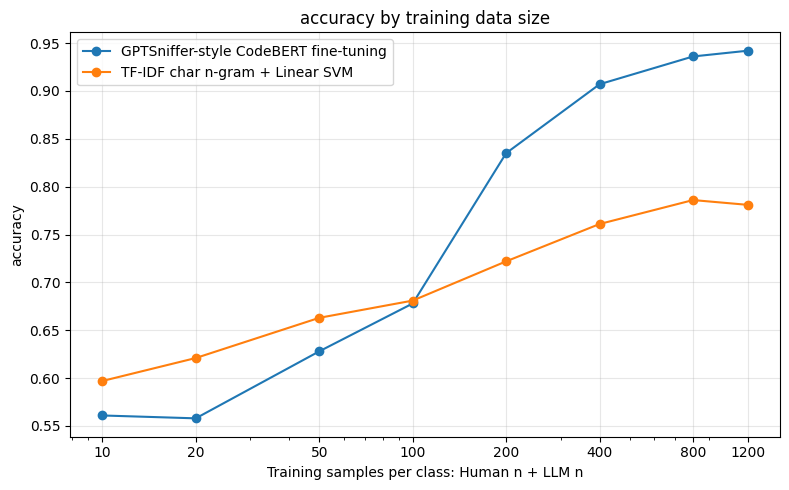

Saved graph: humanvsai_accuracy_by_training_size.png


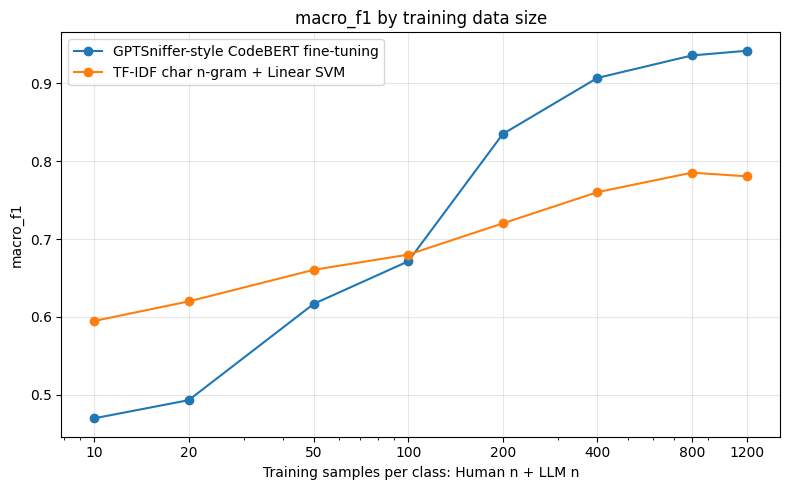

Saved graph: humanvsai_macro_f1_by_training_size.png


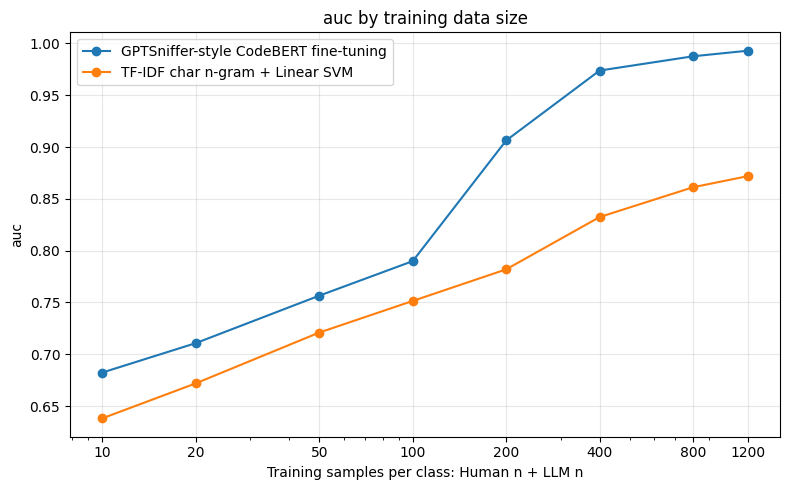

Saved graph: humanvsai_auc_by_training_size.png


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display

all_curve_results = pd.concat(
    [
        svm_curve_df,
        codebert_curve_df
    ],
    ignore_index=True
)

all_curve_results = all_curve_results[
    [
        "model",
        "train_per_class",
        "train_total",
        "split",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "auc"
    ]
].sort_values(["model", "train_per_class"]).reset_index(drop=True)

print("===== Full result table =====")
display(all_curve_results)

# 보기 좋은 반올림 표
rounded_results = all_curve_results.copy()
for col in ["accuracy", "macro_precision", "macro_recall", "macro_f1", "auc"]:
    rounded_results[col] = rounded_results[col].round(4)

print("===== Rounded result table =====")
display(rounded_results)

# CSV 저장
all_curve_results.to_csv("humanvsai_training_size_curve_results.csv", index=False)
rounded_results.to_csv("humanvsai_training_size_curve_results_rounded.csv", index=False)

print("Saved:")
print("- humanvsai_training_size_curve_results.csv")
print("- humanvsai_training_size_curve_results_rounded.csv")


# 논문/발표용 pivot table
pivot_table = rounded_results.pivot_table(
    index=["train_per_class", "train_total"],
    columns="model",
    values=["accuracy", "macro_precision", "macro_recall", "macro_f1", "auc"]
)

print("===== Pivot table =====")
display(pivot_table)


# 그래프 생성
# 논문에는 보통 accuracy, macro_f1, auc 정도만 넣어도 충분합니다.
PLOT_METRICS = ["accuracy", "macro_f1", "auc"]

for metric in PLOT_METRICS:
    plt.figure(figsize=(8, 5))

    for model_name, sub in all_curve_results.groupby("model"):
        sub = sub.sort_values("train_per_class")

        plt.plot(
            sub["train_per_class"],
            sub[metric],
            marker="o",
            label=model_name
        )

    plt.xscale("log")
    plt.xticks(TRAIN_SIZES, TRAIN_SIZES)
    plt.xlabel("Training samples per class: Human n + LLM n")
    plt.ylabel(metric)
    plt.title(f"{metric} by training data size")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = f"humanvsai_{metric}_by_training_size.png"
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved graph: {filename}")